In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [3]:
pca_df = pd.read_csv(os.path.join(path, 'dendro_pca.csv'), index_col=0)

In [4]:
pca_df.set_index(['DATE', 'city'], inplace=True)

In [5]:
pca_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5475 entries, ('1989-01-01', 'BASEL') to ('1989-12-31', 'VALENTIA')
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MONTH             5475 non-null   int64  
 1   cloud_cover       5475 non-null   float64
 2   global_radiation  5475 non-null   float64
 3   humidity          5475 non-null   float64
 4   precipitation     5475 non-null   float64
 5   pressure          5475 non-null   float64
 6   sunshine          5475 non-null   float64
 7   temp_max          5475 non-null   float64
 8   temp_mean         5475 non-null   float64
 9   temp_min          5475 non-null   float64
 10  pleasant_weather  5475 non-null   int64  
 11  0                 5475 non-null   float64
 12  1                 5475 non-null   float64
 13  2                 5475 non-null   float64
 14  3                 5475 non-null   float64
 15  4                 5475 non-null   float64
 16

In [6]:
dendro = pca_df.iloc[:,11:]
dendro.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5475 entries, ('1989-01-01', 'BASEL') to ('1989-12-31', 'VALENTIA')
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5475 non-null   float64
 1   1       5475 non-null   float64
 2   2       5475 non-null   float64
 3   3       5475 non-null   float64
 4   4       5475 non-null   float64
 5   5       5475 non-null   float64
dtypes: float64(6)
memory usage: 284.4+ KB


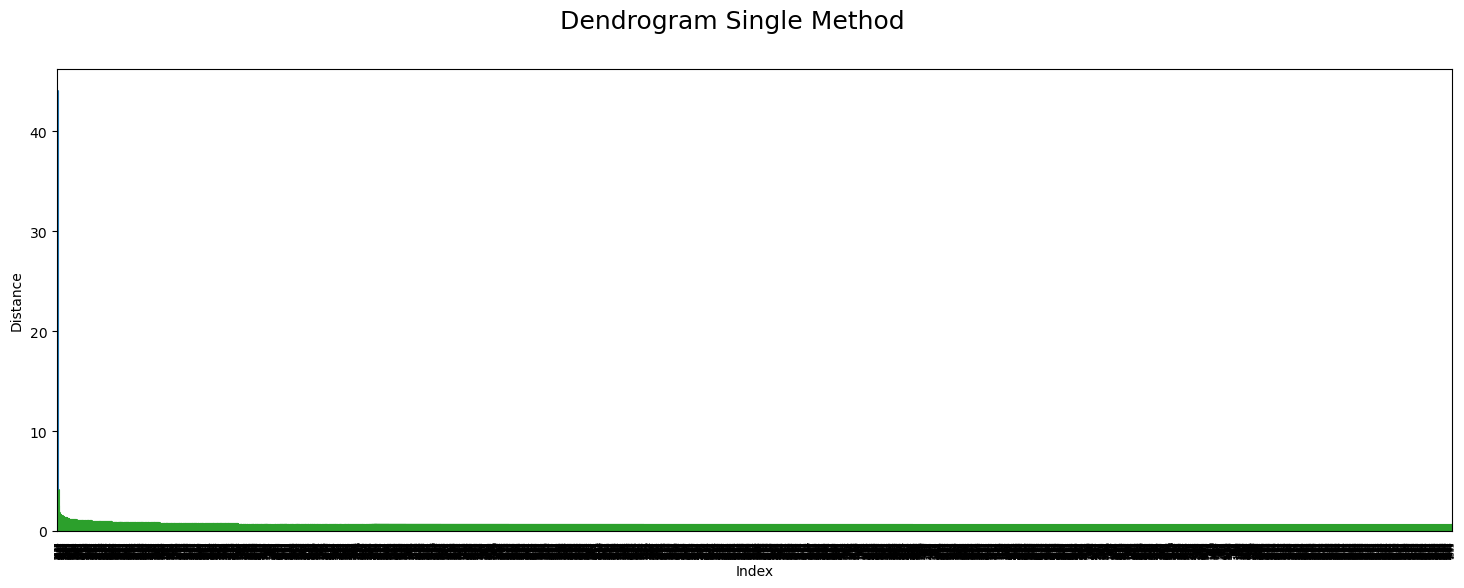

In [12]:
plt.figure(figsize=(18,6))
distance_single = linkage(pca_df.values, method="single")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

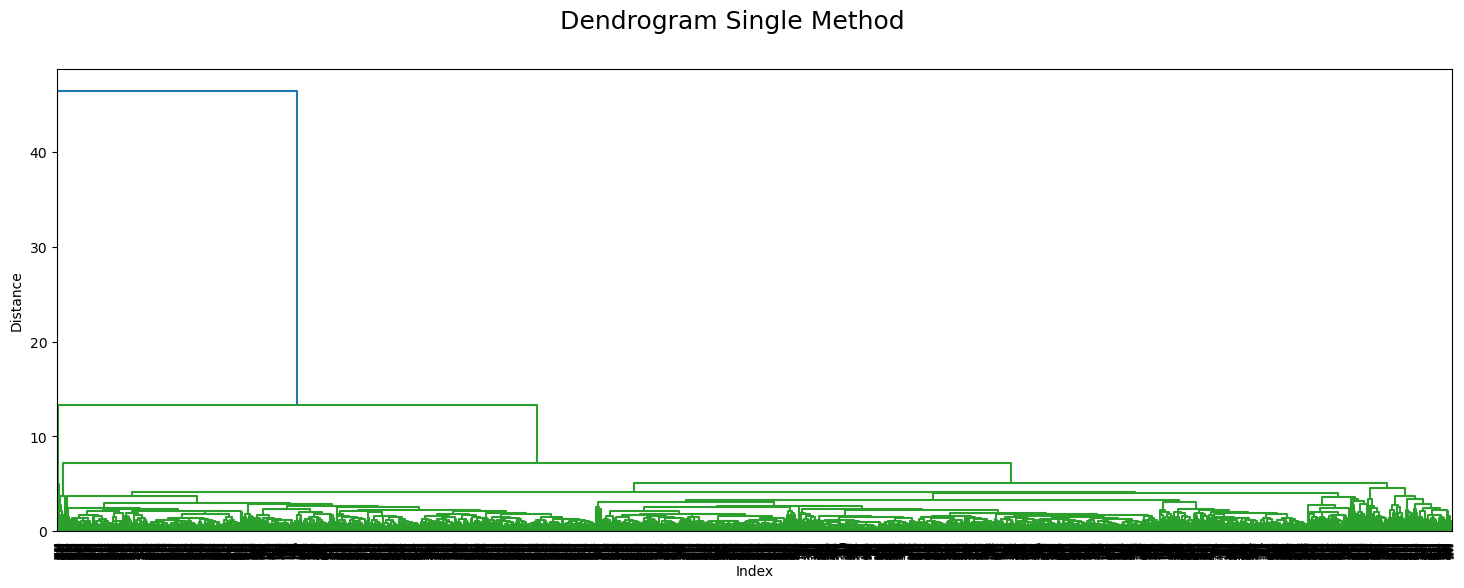

In [11]:
plt.figure(figsize=(18,6))
distance_single = linkage(pca_df.values, method="average")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

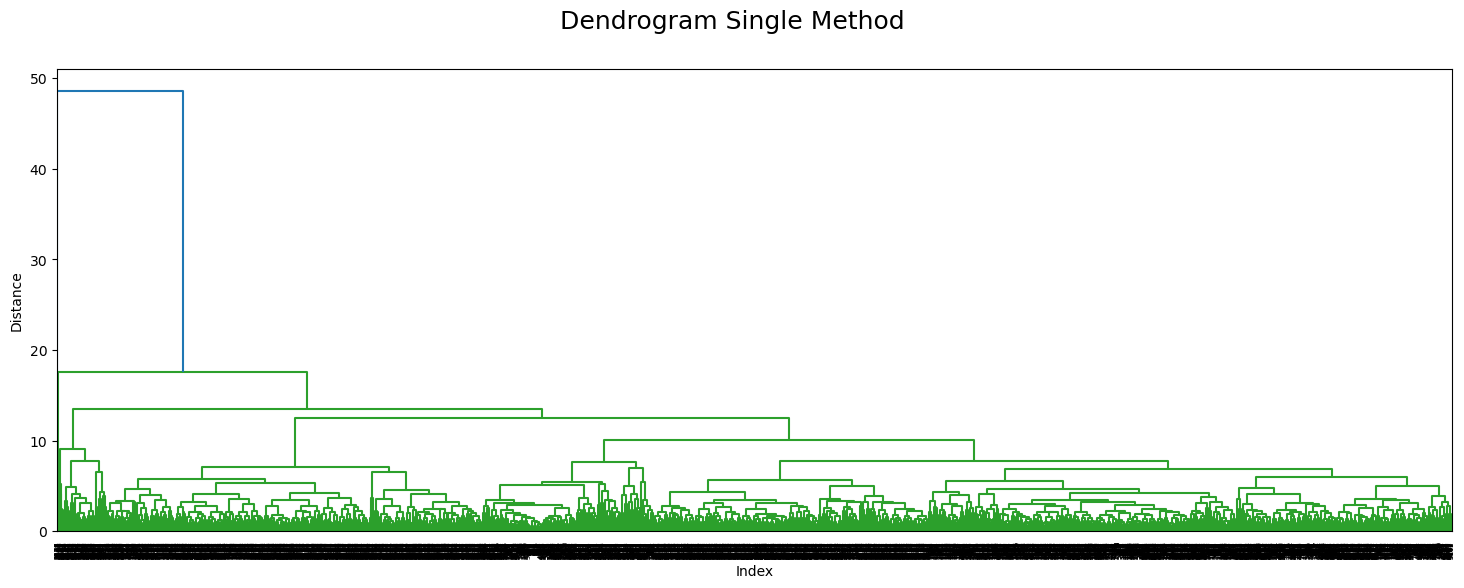

In [9]:
plt.figure(figsize=(18,6))
distance_single = linkage(pca_df.values, method="complete")
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

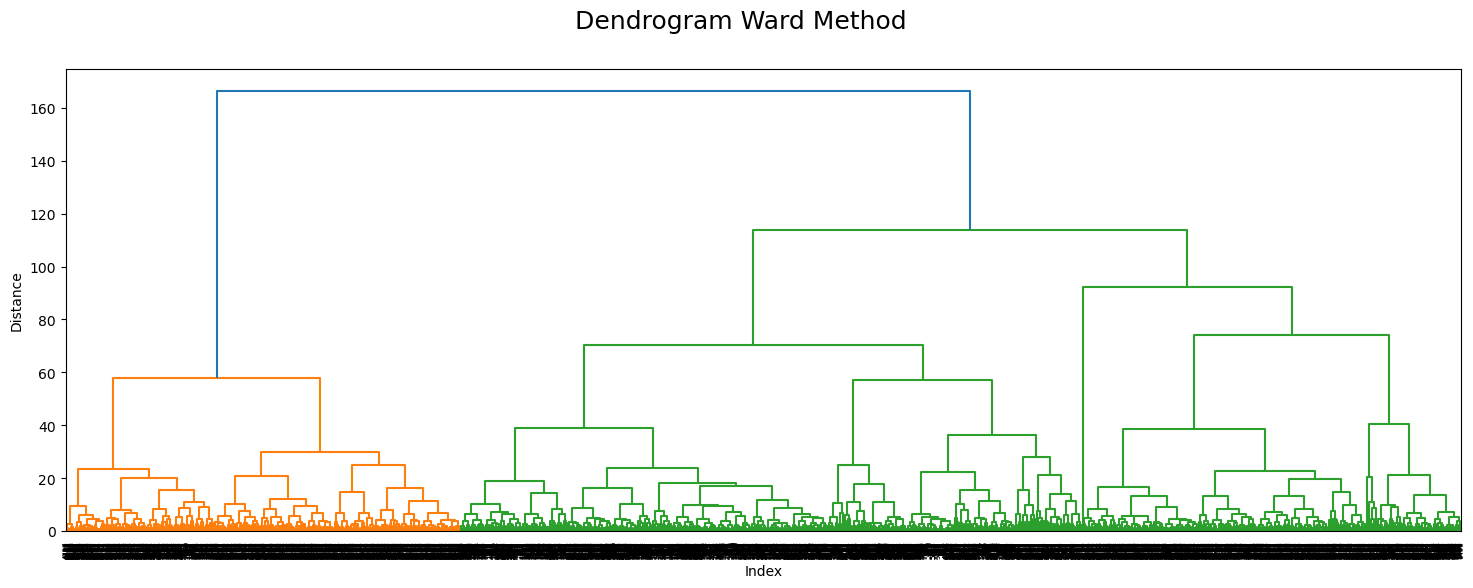

In [7]:
plt.figure(figsize=(18,6))
distance_ward = linkage(dendro, method="ward")
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()

In [15]:
df_PCA_SM=pca_df.copy()

df_PCA_SM['clust2']=fcluster(distance_ward,2, criterion='maxclust')

<Axes: title={'center': 'Weather Pleasantness in PCA Space'}, xlabel='0', ylabel='1'>

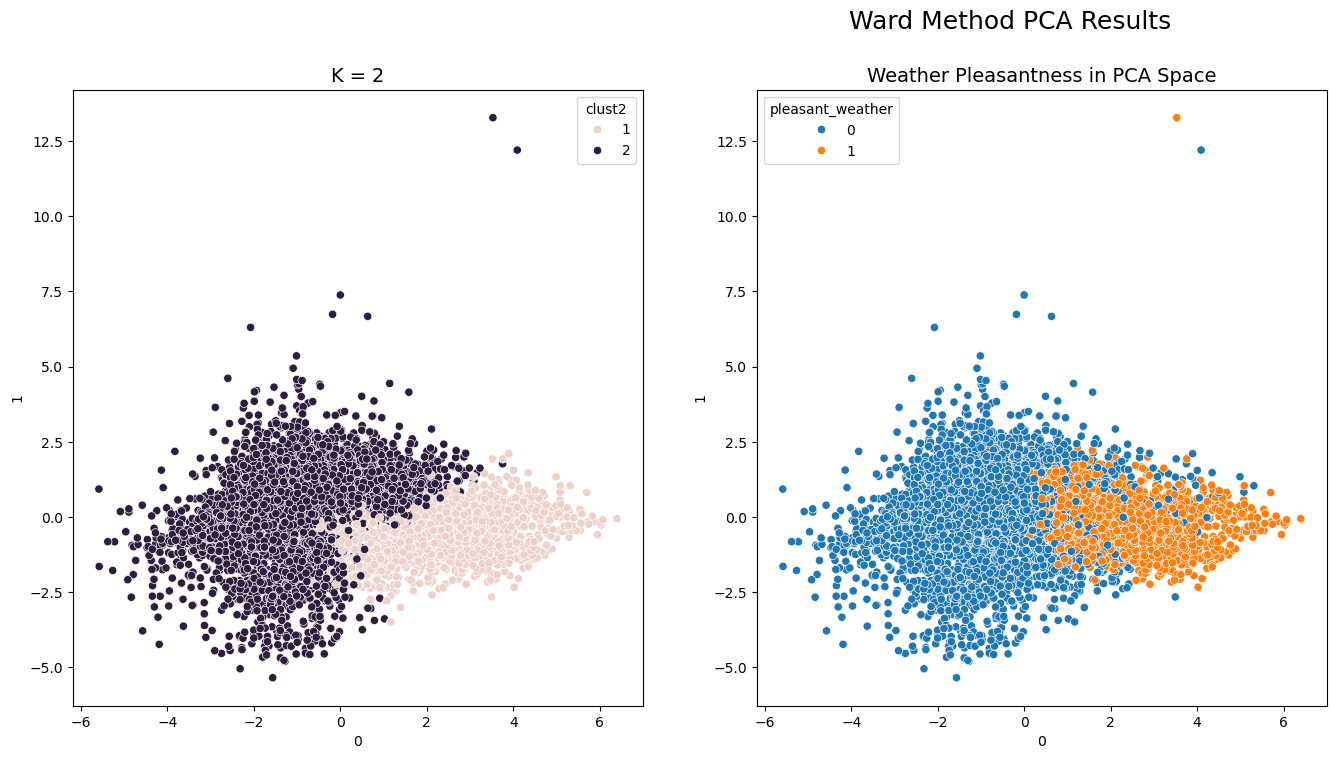

In [17]:
#plot the clusters against the answers
plt.figure(figsize=(25,8))

plt.suptitle("Ward Method PCA Results",fontsize=18)

plt.subplot(1,3,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="0",y="1", data=df_PCA_SM, hue="clust2")

plt.subplot(1,3,2)
plt.title("Weather Pleasantness in PCA Space",fontsize=14)
sns.scatterplot(x="0",y="1", data=df_PCA_SM, hue="pleasant_weather")